In [201]:
import json
import re
from bert_score import score
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import random
import json
import os
import re
from textblob import TextBlob
from scipy.stats import spearmanr, kendalltau

In [260]:
associations_valid = [('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_abstract_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_abstract_prompts_gpt4o_results.jsonl', '2025 GPT4o-Abstract-Zeroshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_abstract_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_abstract_prompts_oneshot_gpt4o_results.jsonl', '2025 GPT4o-Abstract-Oneshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_abstract_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_abstract_prompts_fewshot_gpt4o_results.jsonl', '2025 GPT4o-Abstract-Fewshot'),
                      
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_summary_prompts_gpt4o_results.jsonl', '2025 GPT4o-Summary-Zeroshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_summary_prompts_oneshot_gpt4o_results.jsonl', '2025 GPT4o-Summary-Oneshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_summary_prompts_fewshot_gpt4o_results.jsonl', '2025 GPT4o-Summary-Fewshot'),

                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_full text_prompts_gpt4o_results.jsonl', '2025 GPT4o-Full_Text-Zeroshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_full text_prompts_oneshot_gpt4o_results.jsonl', '2025 GPT4o-Full_Text-Oneshot'),
                      
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/zero_shot_2025_abstract_prompts.jsonl', '2025 Llama-Abstract-Zeroshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/one_shot_2025_abstract_prompts.jsonl', '2025 Llama-Abstract-Oneshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/few_shot_2025_abstract_prompts.jsonl', '2025 Llama-Abstract-Fewshot'),

                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/zero_shot_2025_summary_prompts.jsonl', '2025 Llama-Summary-Zeroshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/one_shot_2025_summary_prompts.jsonl', '2025 Llama-Summary-Oneshot'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/few_shot_2025_summary_prompts.jsonl', '2025 Llama-Summary-Fewshot'),

                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_abstract_prompts_fewshot.jsonl', 'results/hundred_shot_test_data_2025_abstract_prompts.jsonl', '2025 Llama-Abstract-100'),
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_abstract_prompts_fewshot.jsonl', 'results/hundred_shot_test_data_2025_summary_prompts.jsonl', '2025 Llama-Summary-100'),

                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_abstract_prompts_fewshot.jsonl', 'results/thousand_shot_test_data_2025_abstract_prompts.jsonl', '2025 Llama-Abstract-1000'),
                      
                      ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_abstract_prompts_fewshot.jsonl', 'results/time_ordered_instruct_test_data_2025_abstract_prompts_with_timestamp.jsonl', '2025 Llama Time Finetuned'),]

# associations_valid = [('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/zero_shot_2025_summary_prompts.jsonl', 'Llama-Summary-Zeroshot'),
#                       ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/one_shot_2025_summary_prompts.jsonl', 'Llama-Summary-Oneshot'),
#                       ('data/test_data/test_data_without_timestamp/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/few_shot_2025_summary_prompts.jsonl', 'Llama-Summary-Fewshot'),
#                       ('data/test_data/test_data_without_timestamp/few_shot/test_data_2024_summary_prompts_fewshot.jsonl', 'results/llama3_8BInstruct/few_shot_2024_summary_prompts.jsonl', 'Llama-Summary-Fewshot'),]
# #associations_valid = [('data/test_data/few_shot/test_data_2024_abstract_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2024_abstract_prompts_fewshot_gpt4o_results.jsonl', 'GPT4o-Abstract-Fewshot')]

# associations_test = [('data/test_data/few_shot/test_data_2025_abstract_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_abstract_prompts_fewshot_gpt4o_results.jsonl', 'GPT4o-Abstract-Fewshot'),
#                      ('data/test_data/few_shot/test_data_2025_abstract_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_abstract_prompts_oneshot_gpt4o_results.jsonl', 'GPT4o-Abstract-Oneshot'),
#                      ('data/test_data/few_shot/test_data_2025_abstract_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_abstract_prompts_gpt4o_results.jsonl', 'GPT4o-Abstract-Zeroshot'),
#                      ('data/test_data/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_summary_prompts_fewshot_gpt4o_results.jsonl', 'GPT4o-Summary-Fewshot'),
#                      ('data/test_data/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_summary_prompts_oneshot_gpt4o_results.jsonl', 'GPT4o-Summary-Oneshot'),
#                      ('data/test_data/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_summary_prompts_gpt4o_results.jsonl', 'GPT4o-Summary-Zeroshot'),
#                      ('data/test_data/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_full text_prompts_oneshot_gpt4o_results.jsonl', 'GPT4o-Full_Text-Oneshot'),
#                      ('data/test_data/few_shot/test_data_2025_summary_prompts_fewshot.jsonl', 'results/gpt4o/test_data_answer_not_in_prompt/test_data_2025_full text_prompts_gpt4o_results.jsonl', 'GPT4o-Full_Text-Zeroshot')]


In [256]:
from parse_results import fix_missing_quotes_and_braces
def get_gold_and_predictions(association):
    with open(association[0], 'r') as f:
        gold_standard = [json.loads(line) for line in f]
        #gold_standard = json.load(f)

    # with open(association[1], 'r') as f:
    #    predictions = [json.loads(line) for line in f]

    gold_standard = [{item['paper_id']:json.loads(item['messages'][-1]['content'])} for item in gold_standard]
    #predictions = [{item['paper_id']:item['review']} for item in predictions if 'review' in item.keys()]
    #predictions = [{item['paper_id']:json.loads(item['review'])} for item in predictions if 'review' in item.keys()]
    try:
        predictions = [{json.loads(item)['paper_id']: json.loads(json.loads(item)['review'])} for item in fix_missing_quotes_and_braces(association[1], 'test.json')]
    except:
        with open(association[1], 'r') as f:
            predictions = [json.loads(line) for line in f]
        predictions = [{item['paper_id']:item['review']} for item in predictions if 'review' in item.keys()]

    return gold_standard, predictions

device = "mps" if torch.backends.mps.is_available() else "cpu"
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

In [171]:
associations_valid[0]

('data/test_data/few_shot/test_data_2024_summary_prompts_fewshot.jsonl',
 'results/llama3_8BInstruct/one_shot_2024_abstract_prompts.jsonl',
 'Llama-Abstract-Oneshot')

In [194]:
get_gold_and_predictions(associations_valid[0])

JSONDecodeError: Extra data: line 1 column 786 (char 785)

In [122]:
gold_standard, predictions = get_gold_and_predictions(associations_valid[0])
prediction = list(predictions[0].values())[0]
#list([item for item in gold_standard if item.keys() == predictions[0].keys()][0].values())[0]
arr = np.array([])
arr = np.append(arr, [prediction[cat] for cat in numerical_scores])
np.append(arr, [prediction[cat] for cat in numerical_scores]).reshape(-1,5)

JSONDecodeError: Unterminated string starting at: line 9 column 15 (char 1174)

In [69]:
mean_squared_error([1,7, 0],[2,3, 0])

5.666666666666667

In [70]:
def calc_bertscore(gold_cat, pred_cat):
    bert = score(gold_cat.tolist(), pred_cat.tolist(), lang="en")
    mean_precision = torch.mean(bert[0])
    mean_recall = torch.mean(bert[1])
    mean_f1 = torch.mean(bert[2])
    return float(mean_precision), float(mean_recall), float(mean_f1)

In [71]:
def confusion_matrix_gen(num_pred, num_gold):
    num_pred = np.array(num_pred)
    num_gold = np.array(num_gold)

    soundness_conf = confusion_matrix(num_pred[:,0], num_gold[:,0], labels=[1,2,3,4])
    presentation_conf = confusion_matrix(num_pred[:,1], num_gold[:,1], labels=[1,2,3,4])
    contribution_conf = confusion_matrix(num_pred[:,2], num_gold[:,2], labels=[1,2,3,4])
    rating_conf = confusion_matrix(num_pred[:,3], num_gold[:,3], labels=[1,2,3,4,5,6,7,8,9,10])
    confidence_conf = confusion_matrix(num_pred[:,4], num_gold[:,4], labels=[1,2,3,4])

    return(soundness_conf, presentation_conf, contribution_conf, rating_conf, confidence_conf)

In [246]:
def score_results(scores):
    scores_dict = {}
    for score in scores:
        tot_score = 0
        for key in ['Soundness', 'Presentation', 'Contribution', 'Rating', 'Confidence']:
            tot_score += list(score.values())[0][key]
        try:
            list(score.values())[0]['Weaknesses']
            tot_score += (TextBlob(list(score.values())[0]['Strengths']).sentiment.polarity - np.abs(TextBlob(list(score.values())[0]['Weaknesses']).sentiment.polarity))
        except:
            tot_score += 0
        scores_dict[list(score.keys())[0]] = tot_score
    sorted_items = sorted(scores_dict.items(), key=lambda item: item[1], reverse=True)
    ranked_values = {}
    rank = 1
    for key, value in sorted_items:
        ranked_values[key] = rank
        rank += 1
    return ranked_values

In [202]:
def top_nk(n, k, gold_scores_rank, pred_scores_rank):
    top_n = list(gold_scores_rank)[0:int(n*len(gold_scores_rank)/100)]
    top_k = list(pred_scores_rank)[0:int(k*len(pred_scores_rank)/100)]
    return len(set(top_n).intersection(set(top_k)))

In [234]:
def filter_by_rating(data, threshold=5):
    return {k: v['Rating'] for item in data for k, v in item.items() if v['Rating'] > threshold}

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


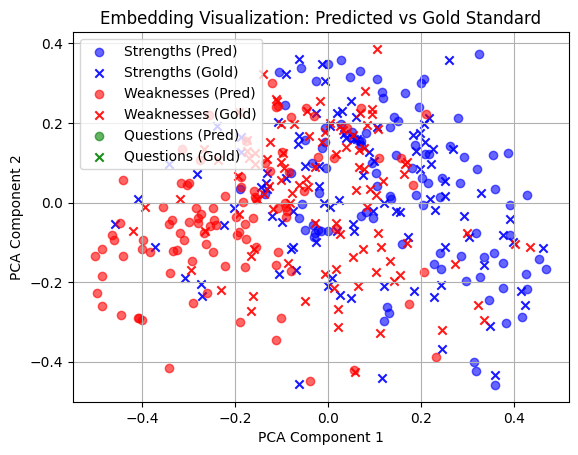

2025 GPT4o-Abstract-Zeroshot MSE_soundness = 1.38
2025 GPT4o-Abstract-Zeroshot MSE_presentation = 1.13
2025 GPT4o-Abstract-Zeroshot MSE_contribution = 2.25
2025 GPT4o-Abstract-Zeroshot MSE_rating = 6.86
2025 GPT4o-Abstract-Zeroshot MSE_confidence = 0.75
2025 GPT4o-Abstract-Zeroshot Strengths_BertScore = 0.8544164896011353 / 0.8715487122535706 / 0.8626866340637207
2025 GPT4o-Abstract-Zeroshot Weaknesses_BertScore = 0.8065940737724304 / 0.8563406467437744 / 0.8305208086967468
2025 GPT4o-Abstract-Zeroshot Rank_Spearman = Stat:0.318043804380438 P-Value:0.001261432915132484
2025 GPT4o-Abstract-Zeroshot Rank_Kendall = Stat:0.2161616161616162 P-Value:0.0014396319713756935
2025 GPT4o-Abstract-Zeroshot Top_5_5 = 1 Top_5_25 = 3 Top_10_10 = 1 Top_10_50 = 6 Top_20_20 = 10 Top_20_50 = 15
2025 GPT4o-Abstract-Zeroshot Confusion Matrix = [[56  0]
 [44  0]]




Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


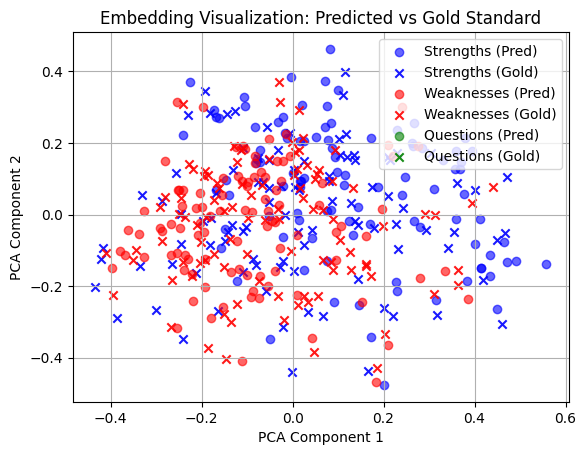

2025 GPT4o-Abstract-Oneshot MSE_soundness = 1.9292929292929293
2025 GPT4o-Abstract-Oneshot MSE_presentation = 1.6363636363636365
2025 GPT4o-Abstract-Oneshot MSE_contribution = 2.2525252525252526
2025 GPT4o-Abstract-Oneshot MSE_rating = 8.272727272727273
2025 GPT4o-Abstract-Oneshot MSE_confidence = 0.7878787878787878
2025 GPT4o-Abstract-Oneshot Strengths_BertScore = 0.8633936047554016 / 0.8627087473869324 / 0.8628808856010437
2025 GPT4o-Abstract-Oneshot Weaknesses_BertScore = 0.815331757068634 / 0.8572753071784973 / 0.8355696797370911
2025 GPT4o-Abstract-Oneshot Rank_Spearman = Stat:0.24968460111317253 P-Value:0.012688702441807904
2025 GPT4o-Abstract-Oneshot Rank_Kendall = Stat:0.15563801278086994 P-Value:0.022461770339049773
2025 GPT4o-Abstract-Oneshot Top_5_5 = 0 Top_5_25 = 1 Top_10_10 = 1 Top_10_50 = 4 Top_20_20 = 4 Top_20_50 = 13
2025 GPT4o-Abstract-Oneshot Confusion Matrix = [[56  0]
 [43  0]]




Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


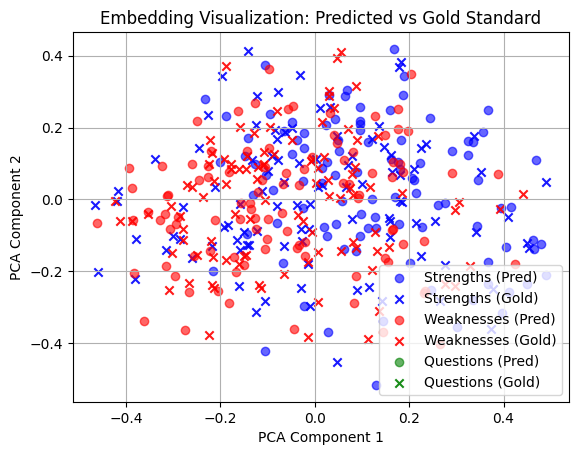

2025 GPT4o-Abstract-Fewshot MSE_soundness = 1.65
2025 GPT4o-Abstract-Fewshot MSE_presentation = 1.25
2025 GPT4o-Abstract-Fewshot MSE_contribution = 1.94
2025 GPT4o-Abstract-Fewshot MSE_rating = 7.89
2025 GPT4o-Abstract-Fewshot MSE_confidence = 0.75
2025 GPT4o-Abstract-Fewshot Strengths_BertScore = 0.8602344989776611 / 0.8619611859321594 / 0.8609210848808289
2025 GPT4o-Abstract-Fewshot Weaknesses_BertScore = 0.8141819834709167 / 0.8538875579833984 / 0.8333448767662048
2025 GPT4o-Abstract-Fewshot Rank_Spearman = Stat:0.24895289528952894 P-Value:0.012500667278479885
2025 GPT4o-Abstract-Fewshot Rank_Kendall = Stat:0.15353535353535355 P-Value:0.023612966933681312
2025 GPT4o-Abstract-Fewshot Top_5_5 = 0 Top_5_25 = 0 Top_10_10 = 1 Top_10_50 = 8 Top_20_20 = 4 Top_20_50 = 13
2025 GPT4o-Abstract-Fewshot Confusion Matrix = [[56  0]
 [44  0]]




Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


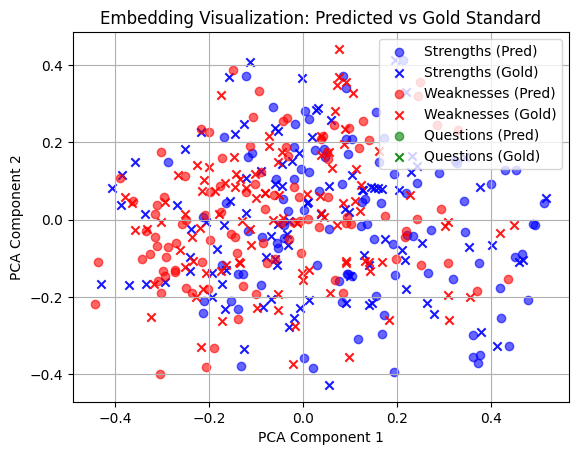

2025 GPT4o-Summary-Zeroshot MSE_soundness = 1.7
2025 GPT4o-Summary-Zeroshot MSE_presentation = 1.19
2025 GPT4o-Summary-Zeroshot MSE_contribution = 2.38
2025 GPT4o-Summary-Zeroshot MSE_rating = 7.66
2025 GPT4o-Summary-Zeroshot MSE_confidence = 0.86
2025 GPT4o-Summary-Zeroshot Strengths_BertScore = 0.8563329577445984 / 0.8699345588684082 / 0.8628808856010437
2025 GPT4o-Summary-Zeroshot Weaknesses_BertScore = 0.808958888053894 / 0.855903148651123 / 0.8315746188163757
2025 GPT4o-Summary-Zeroshot Rank_Spearman = Stat:0.19987998799879986 P-Value:0.04616970318782704
2025 GPT4o-Summary-Zeroshot Rank_Kendall = Stat:0.13454545454545458 P-Value:0.0473198897932448
2025 GPT4o-Summary-Zeroshot Top_5_5 = 0 Top_5_25 = 1 Top_10_10 = 2 Top_10_50 = 8 Top_20_20 = 7 Top_20_50 = 14
2025 GPT4o-Summary-Zeroshot Confusion Matrix = [[56  0]
 [44  0]]




Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


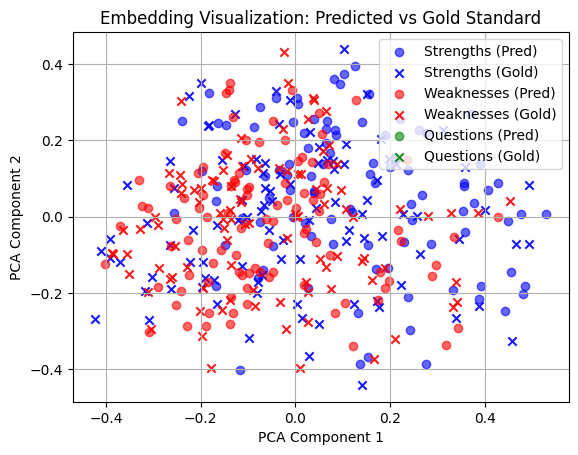

2025 GPT4o-Summary-Oneshot MSE_soundness = 1.6868686868686869
2025 GPT4o-Summary-Oneshot MSE_presentation = 1.595959595959596
2025 GPT4o-Summary-Oneshot MSE_contribution = 1.97979797979798
2025 GPT4o-Summary-Oneshot MSE_rating = 7.626262626262626
2025 GPT4o-Summary-Oneshot MSE_confidence = 0.8282828282828283
2025 GPT4o-Summary-Oneshot Strengths_BertScore = 0.8657658100128174 / 0.8626787662506104 / 0.864041268825531
2025 GPT4o-Summary-Oneshot Weaknesses_BertScore = 0.818264901638031 / 0.8556108474731445 / 0.836326539516449
2025 GPT4o-Summary-Oneshot Rank_Spearman = Stat:0.20352504638218924 P-Value:0.04332839814186717
2025 GPT4o-Summary-Oneshot Rank_Kendall = Stat:0.13090084518655948 P-Value:0.05489694457397477
2025 GPT4o-Summary-Oneshot Top_5_5 = 0 Top_5_25 = 2 Top_10_10 = 0 Top_10_50 = 6 Top_20_20 = 6 Top_20_50 = 14
2025 GPT4o-Summary-Oneshot Confusion Matrix = [[55  1]
 [44  0]]




Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


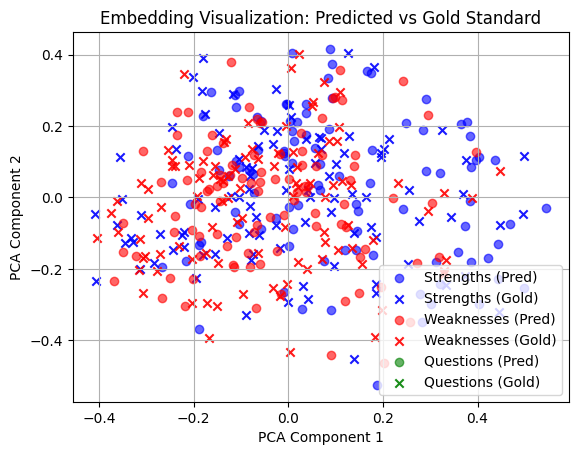

2025 GPT4o-Summary-Fewshot MSE_soundness = 1.57
2025 GPT4o-Summary-Fewshot MSE_presentation = 1.23
2025 GPT4o-Summary-Fewshot MSE_contribution = 1.76
2025 GPT4o-Summary-Fewshot MSE_rating = 7.36
2025 GPT4o-Summary-Fewshot MSE_confidence = 0.84
2025 GPT4o-Summary-Fewshot Strengths_BertScore = 0.8630234003067017 / 0.8637021780014038 / 0.8631737232208252
2025 GPT4o-Summary-Fewshot Weaknesses_BertScore = 0.8169681429862976 / 0.853742241859436 / 0.8347408771514893
2025 GPT4o-Summary-Fewshot Rank_Spearman = Stat:0.14371437143714372 P-Value:0.15372641271159465
2025 GPT4o-Summary-Fewshot Rank_Kendall = Stat:0.0985858585858586 P-Value:0.14613465142368906
2025 GPT4o-Summary-Fewshot Top_5_5 = 1 Top_5_25 = 2 Top_10_10 = 2 Top_10_50 = 8 Top_20_20 = 5 Top_20_50 = 14
2025 GPT4o-Summary-Fewshot Confusion Matrix = [[56  0]
 [44  0]]




Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


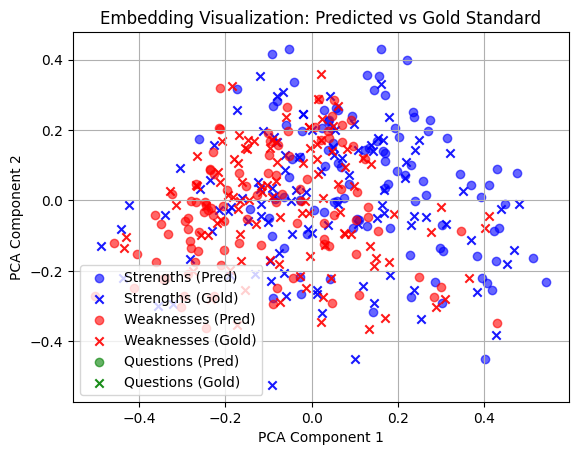

2025 GPT4o-Full_Text-Zeroshot MSE_soundness = 1.19
2025 GPT4o-Full_Text-Zeroshot MSE_presentation = 0.97
2025 GPT4o-Full_Text-Zeroshot MSE_contribution = 1.84
2025 GPT4o-Full_Text-Zeroshot MSE_rating = 6.11
2025 GPT4o-Full_Text-Zeroshot MSE_confidence = 0.69
2025 GPT4o-Full_Text-Zeroshot Strengths_BertScore = 0.858753502368927 / 0.8695774078369141 / 0.8639423847198486
2025 GPT4o-Full_Text-Zeroshot Weaknesses_BertScore = 0.8110246062278748 / 0.8560861945152283 / 0.8327318429946899
2025 GPT4o-Full_Text-Zeroshot Rank_Spearman = Stat:0.21158115811581155 P-Value:0.034583883992097206
2025 GPT4o-Full_Text-Zeroshot Rank_Kendall = Stat:0.14262626262626263 P-Value:0.03550508500881739
2025 GPT4o-Full_Text-Zeroshot Top_5_5 = 1 Top_5_25 = 2 Top_10_10 = 2 Top_10_50 = 7 Top_20_20 = 6 Top_20_50 = 12
2025 GPT4o-Full_Text-Zeroshot Confusion Matrix = [[55  1]
 [43  0]]




Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


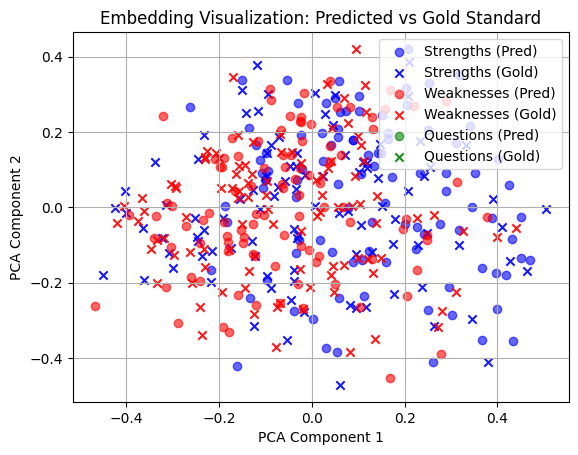

2025 GPT4o-Full_Text-Oneshot MSE_soundness = 1.67
2025 GPT4o-Full_Text-Oneshot MSE_presentation = 1.77
2025 GPT4o-Full_Text-Oneshot MSE_contribution = 1.9
2025 GPT4o-Full_Text-Oneshot MSE_rating = 7.12
2025 GPT4o-Full_Text-Oneshot MSE_confidence = 0.73
2025 GPT4o-Full_Text-Oneshot Strengths_BertScore = 0.8661414384841919 / 0.8620779514312744 / 0.8639384508132935
2025 GPT4o-Full_Text-Oneshot Weaknesses_BertScore = 0.8188620805740356 / 0.8535429239273071 / 0.8356228470802307
2025 GPT4o-Full_Text-Oneshot Rank_Spearman = Stat:0.2748514851485148 P-Value:0.005649307188132052
2025 GPT4o-Full_Text-Oneshot Rank_Kendall = Stat:0.18222222222222226 P-Value:0.007225654722718255
2025 GPT4o-Full_Text-Oneshot Top_5_5 = 0 Top_5_25 = 1 Top_10_10 = 0 Top_10_50 = 5 Top_20_20 = 4 Top_20_50 = 13
2025 GPT4o-Full_Text-Oneshot Confusion Matrix = [[56  0]
 [43  0]]




Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


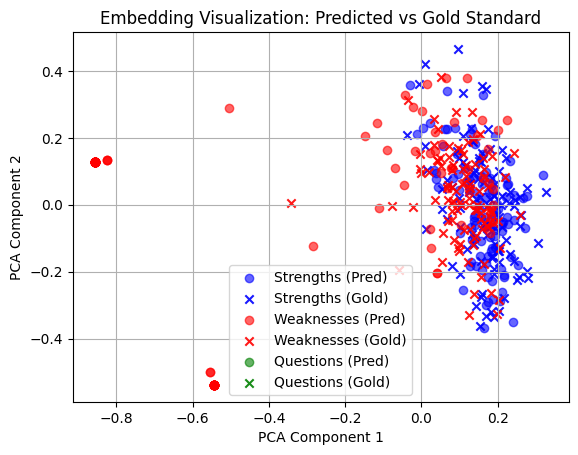

2025 Llama-Abstract-Zeroshot MSE_soundness = 2.13
2025 Llama-Abstract-Zeroshot MSE_presentation = 1.8
2025 Llama-Abstract-Zeroshot MSE_contribution = 2.65
2025 Llama-Abstract-Zeroshot MSE_rating = 14.52
2025 Llama-Abstract-Zeroshot MSE_confidence = 2.5
2025 Llama-Abstract-Zeroshot Strengths_BertScore = 0.8400630354881287 / 0.8639117479324341 / 0.8516597747802734
2025 Llama-Abstract-Zeroshot Weaknesses_BertScore = 0.771746814250946 / 0.8403439521789551 / 0.8043201565742493
2025 Llama-Abstract-Zeroshot Rank_Spearman = Stat:0.15867986798679867 P-Value:0.11482844957561254
2025 Llama-Abstract-Zeroshot Rank_Kendall = Stat:0.10343434343434345 P-Value:0.12731003900366167
2025 Llama-Abstract-Zeroshot Top_5_5 = 0 Top_5_25 = 2 Top_10_10 = 2 Top_10_50 = 6 Top_20_20 = 5 Top_20_50 = 13
2025 Llama-Abstract-Zeroshot Confusion Matrix = [[56  0]
 [44  0]]


Line 22: Could not fix JSON by appending braces/quotes. Skipping.
  Original line: {"paper_id": "gRuZkEy49k", "review": "{\n  \"Soundness\": 4,\n  \

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


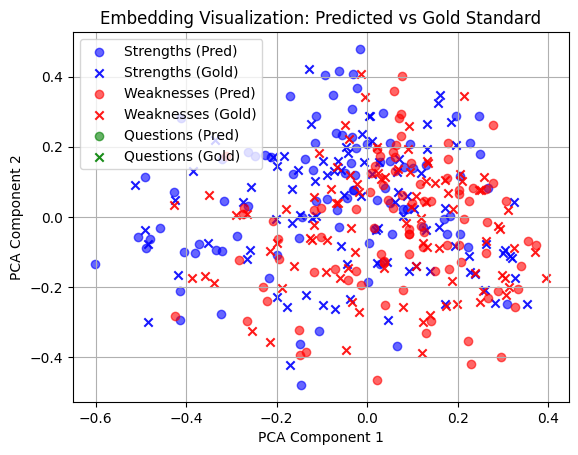

2025 Llama-Abstract-Oneshot MSE_soundness = 2.021978021978022
2025 Llama-Abstract-Oneshot MSE_presentation = 2.098901098901099
2025 Llama-Abstract-Oneshot MSE_contribution = 2.4945054945054945
2025 Llama-Abstract-Oneshot MSE_rating = 12.659340659340659
2025 Llama-Abstract-Oneshot MSE_confidence = 2.230769230769231
2025 Llama-Abstract-Oneshot Strengths_BertScore = 0.8686661124229431 / 0.865205705165863 / 0.8667336106300354
2025 Llama-Abstract-Oneshot Weaknesses_BertScore = 0.8097363114356995 / 0.8503517508506775 / 0.8293306231498718
2025 Llama-Abstract-Oneshot Rank_Spearman = Stat:0.017996496257365824 P-Value:0.8655480107994523
2025 Llama-Abstract-Oneshot Rank_Kendall = Stat:0.013919413919413919 P-Value:0.8450714358982988
2025 Llama-Abstract-Oneshot Top_5_5 = 0 Top_5_25 = 0 Top_10_10 = 0 Top_10_50 = 5 Top_20_20 = 3 Top_20_50 = 8
2025 Llama-Abstract-Oneshot Confusion Matrix = [[52  4]
 [39  0]]


Line 2: Could not fix JSON by appending braces/quotes. Skipping.
  Original line: {"paper_id

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


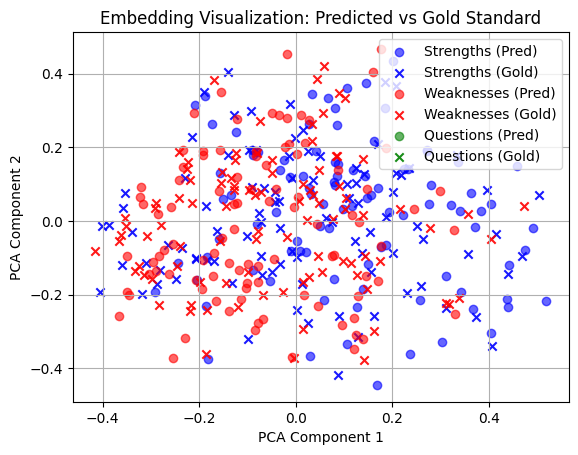

2025 Llama-Abstract-Fewshot MSE_soundness = 1.40625
2025 Llama-Abstract-Fewshot MSE_presentation = 1.8125
2025 Llama-Abstract-Fewshot MSE_contribution = 2.0
2025 Llama-Abstract-Fewshot MSE_rating = 13.260416666666666
2025 Llama-Abstract-Fewshot MSE_confidence = 1.6458333333333333
2025 Llama-Abstract-Fewshot Strengths_BertScore = 0.8620693683624268 / 0.863417387008667 / 0.8625316023826599
2025 Llama-Abstract-Fewshot Weaknesses_BertScore = 0.818925678730011 / 0.859592854976654 / 0.8385405540466309
2025 Llama-Abstract-Fewshot Rank_Spearman = Stat:0.08319316332067281 P-Value:0.4203329445164341
2025 Llama-Abstract-Fewshot Rank_Kendall = Stat:0.05877192982456139 P-Value:0.3962806539115912
2025 Llama-Abstract-Fewshot Top_5_5 = 1 Top_5_25 = 2 Top_10_10 = 1 Top_10_50 = 5 Top_20_20 = 4 Top_20_50 = 10
2025 Llama-Abstract-Fewshot Confusion Matrix = [[53  3]
 [43  0]]


Line 1: Could not fix JSON by appending braces/quotes. Skipping.
  Original line: {"paper_id": "u3xwwfHmBC", "review": "{\n  \"Sou

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


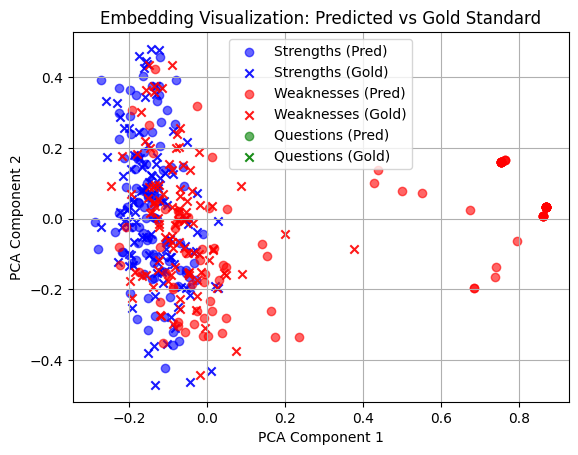

2025 Llama-Summary-Zeroshot MSE_soundness = 2.13265306122449
2025 Llama-Summary-Zeroshot MSE_presentation = 2.020408163265306
2025 Llama-Summary-Zeroshot MSE_contribution = 2.7448979591836733
2025 Llama-Summary-Zeroshot MSE_rating = 14.744897959183673
2025 Llama-Summary-Zeroshot MSE_confidence = 2.642857142857143
2025 Llama-Summary-Zeroshot Strengths_BertScore = 0.8403946161270142 / 0.8638449907302856 / 0.8517759442329407
2025 Llama-Summary-Zeroshot Weaknesses_BertScore = 0.7892476320266724 / 0.8518620133399963 / 0.8191566467285156
2025 Llama-Summary-Zeroshot Rank_Spearman = Stat:0.047555292032464336 P-Value:0.6419341035042265
2025 Llama-Summary-Zeroshot Rank_Kendall = Stat:0.027982326951399118 P-Value:0.6831144560204427
2025 Llama-Summary-Zeroshot Top_5_5 = 0 Top_5_25 = 0 Top_10_10 = 0 Top_10_50 = 5 Top_20_20 = 3 Top_20_50 = 9
2025 Llama-Summary-Zeroshot Confusion Matrix = [[55  1]
 [43  0]]


Line 17: Could not fix JSON by appending braces/quotes. Skipping.
  Original line: {"paper_i

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


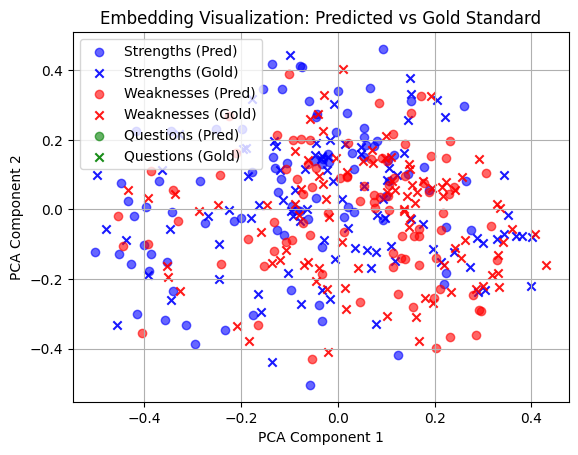

2025 Llama-Summary-Oneshot MSE_soundness = 1.3846153846153846
2025 Llama-Summary-Oneshot MSE_presentation = 1.934065934065934
2025 Llama-Summary-Oneshot MSE_contribution = 2.032967032967033
2025 Llama-Summary-Oneshot MSE_rating = 11.164835164835164
2025 Llama-Summary-Oneshot MSE_confidence = 1.7472527472527473
2025 Llama-Summary-Oneshot Strengths_BertScore = 0.865881621837616 / 0.8658209443092346 / 0.8656871318817139
2025 Llama-Summary-Oneshot Weaknesses_BertScore = 0.8208333849906921 / 0.8598095178604126 / 0.8396721482276917
2025 Llama-Summary-Oneshot Rank_Spearman = Stat:0.06297181079789775 P-Value:0.5531827499159332
2025 Llama-Summary-Oneshot Rank_Kendall = Stat:0.04371184371184371 P-Value:0.5394412273047411
2025 Llama-Summary-Oneshot Top_5_5 = 0 Top_5_25 = 1 Top_10_10 = 1 Top_10_50 = 5 Top_20_20 = 3 Top_20_50 = 10
2025 Llama-Summary-Oneshot Confusion Matrix = [[52  4]
 [39  0]]


Line 40: Could not fix JSON by appending braces/quotes. Skipping.
  Original line: {"paper_id": "OdMqKs

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


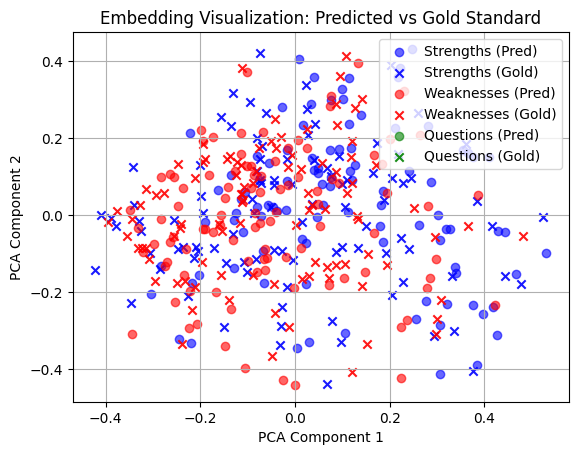

2025 Llama-Summary-Fewshot MSE_soundness = 1.2040816326530612
2025 Llama-Summary-Fewshot MSE_presentation = 1.4489795918367347
2025 Llama-Summary-Fewshot MSE_contribution = 1.8571428571428572
2025 Llama-Summary-Fewshot MSE_rating = 12.938775510204081
2025 Llama-Summary-Fewshot MSE_confidence = 1.3877551020408163
2025 Llama-Summary-Fewshot Strengths_BertScore = 0.8622972965240479 / 0.8651161789894104 / 0.8635040521621704
2025 Llama-Summary-Fewshot Weaknesses_BertScore = 0.8168489336967468 / 0.8579200506210327 / 0.836665153503418
2025 Llama-Summary-Fewshot Rank_Spearman = Stat:0.20648521826725066 P-Value:0.04135914276928322
2025 Llama-Summary-Fewshot Rank_Kendall = Stat:0.1483273721859878 P-Value:0.030475372176724646
2025 Llama-Summary-Fewshot Top_5_5 = 1 Top_5_25 = 2 Top_10_10 = 3 Top_10_50 = 8 Top_20_20 = 6 Top_20_50 = 16
2025 Llama-Summary-Fewshot Confusion Matrix = [[55  1]
 [43  0]]


Line 58: Could not fix JSON by appending braces/quotes. Skipping.
  Original line: {"paper_id": "Ui

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


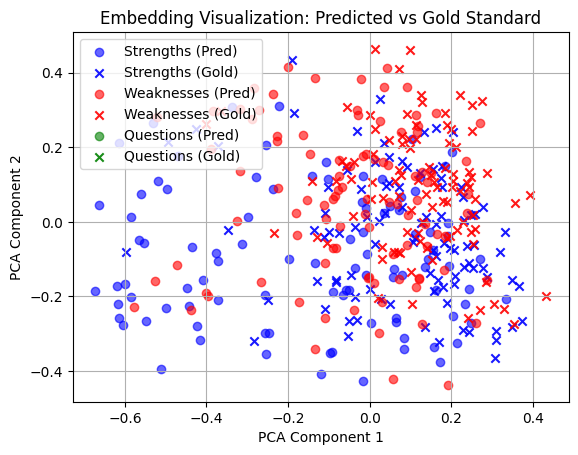

2025 Llama-Abstract-100 MSE_soundness = 0.7319587628865979
2025 Llama-Abstract-100 MSE_presentation = 0.8247422680412371
2025 Llama-Abstract-100 MSE_contribution = 0.7835051546391752
2025 Llama-Abstract-100 MSE_rating = 6.185567010309279
2025 Llama-Abstract-100 MSE_confidence = 0.9690721649484536
2025 Llama-Abstract-100 Strengths_BertScore = 0.8535096645355225 / 0.88007652759552 / 0.8663458824157715
2025 Llama-Abstract-100 Weaknesses_BertScore = 0.8207377195358276 / 0.8467504978179932 / 0.8332484364509583
2025 Llama-Abstract-100 Rank_Spearman = Stat:-0.030717441615821583 P-Value:0.7651839987109404
2025 Llama-Abstract-100 Rank_Kendall = Stat:-0.020189003436426118 P-Value:0.7695487264404447
2025 Llama-Abstract-100 Top_5_5 = 0 Top_5_25 = 1 Top_10_10 = 0 Top_10_50 = 6 Top_20_20 = 1 Top_20_50 = 12
2025 Llama-Abstract-100 Confusion Matrix = [[27 29]
 [19  0]]


Line 4: Could not fix JSON by appending braces/quotes. Skipping.
  Original line: {"paper_id": "gx3LMRB15C", "review": "{\"Soundness

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


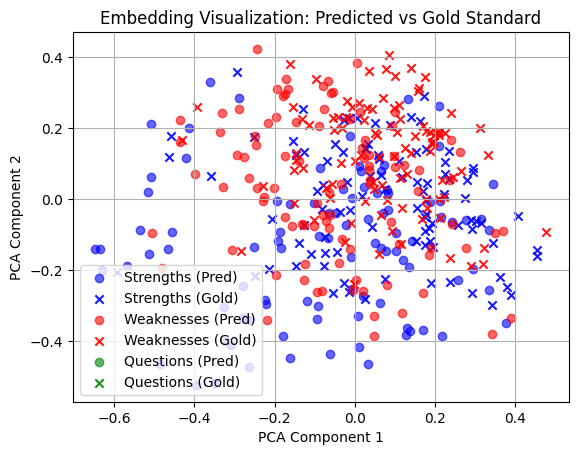

2025 Llama-Summary-100 MSE_soundness = 0.6770833333333334
2025 Llama-Summary-100 MSE_presentation = 0.8020833333333334
2025 Llama-Summary-100 MSE_contribution = 0.6145833333333334
2025 Llama-Summary-100 MSE_rating = 6.21875
2025 Llama-Summary-100 MSE_confidence = 0.8541666666666666
2025 Llama-Summary-100 Strengths_BertScore = 0.8546110987663269 / 0.882559061050415 / 0.8681354522705078
2025 Llama-Summary-100 Weaknesses_BertScore = 0.8194912075996399 / 0.8481839299201965 / 0.8332781791687012
2025 Llama-Summary-100 Rank_Spearman = Stat:0.04358383071079761 P-Value:0.6732884481156822
2025 Llama-Summary-100 Rank_Kendall = Stat:0.027192982456140345 P-Value:0.6946969935927938
2025 Llama-Summary-100 Top_5_5 = 0 Top_5_25 = 1 Top_10_10 = 0 Top_10_50 = 5 Top_20_20 = 5 Top_20_50 = 11
2025 Llama-Summary-100 Confusion Matrix = [[24 32]
 [15  0]]


Line 64: Could not fix JSON by appending braces/quotes. Skipping.
  Original line: {"paper_id": "sec09tLQUl", "review": "{\"Soundness\": 3, \"Presentation\

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


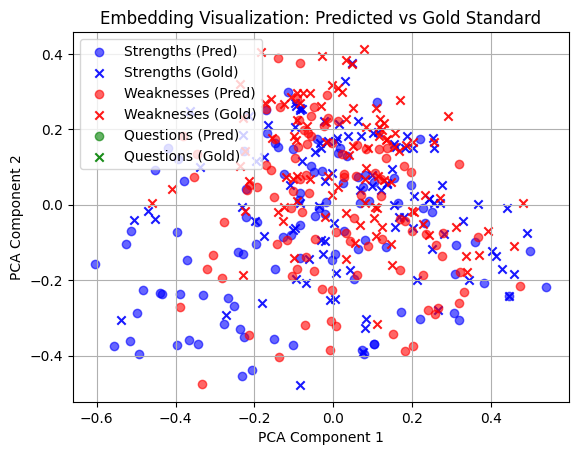

2025 Llama-Abstract-1000 MSE_soundness = 0.7373737373737373
2025 Llama-Abstract-1000 MSE_presentation = 0.797979797979798
2025 Llama-Abstract-1000 MSE_contribution = 0.6868686868686869
2025 Llama-Abstract-1000 MSE_rating = 5.252525252525253
2025 Llama-Abstract-1000 MSE_confidence = 0.7575757575757576
2025 Llama-Abstract-1000 Strengths_BertScore = 0.8521520495414734 / 0.8811490535736084 / 0.8661757707595825
2025 Llama-Abstract-1000 Weaknesses_BertScore = 0.813251793384552 / 0.8406529426574707 / 0.8264533877372742
2025 Llama-Abstract-1000 Rank_Spearman = Stat:-0.00852195423623995 P-Value:0.9332814399326592
2025 Llama-Abstract-1000 Rank_Kendall = Stat:-0.005978148835291693 P-Value:0.930138227885474
2025 Llama-Abstract-1000 Top_5_5 = 0 Top_5_25 = 1 Top_10_10 = 1 Top_10_50 = 5 Top_20_20 = 4 Top_20_50 = 10
2025 Llama-Abstract-1000 Confusion Matrix = [[24 32]
 [20  0]]


Line 2: Could not fix JSON by appending braces/quotes. Skipping.
  Original line: {"paper_id": "dgR6i4TSng", "review": "{\"

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


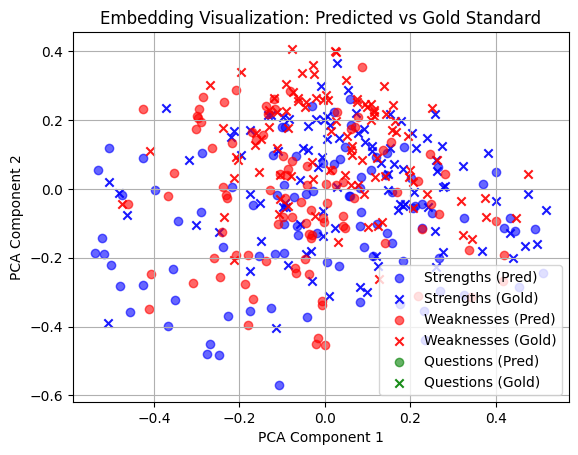

2025 Llama Time Finetuned MSE_soundness = 0.7291666666666666
2025 Llama Time Finetuned MSE_presentation = 0.7291666666666666
2025 Llama Time Finetuned MSE_contribution = 0.8125
2025 Llama Time Finetuned MSE_rating = 4.90625
2025 Llama Time Finetuned MSE_confidence = 1.0833333333333333
2025 Llama Time Finetuned Strengths_BertScore = 0.855548083782196 / 0.8776938319206238 / 0.8662011027336121
2025 Llama Time Finetuned Weaknesses_BertScore = 0.8195622563362122 / 0.8462507724761963 / 0.8324375748634338
2025 Llama Time Finetuned Rank_Spearman = Stat:-0.11338849701573522 P-Value:0.2713432263568843
2025 Llama Time Finetuned Rank_Kendall = Stat:-0.06929824561403508 P-Value:0.3172070960462492
2025 Llama Time Finetuned Top_5_5 = 0 Top_5_25 = 0 Top_10_10 = 1 Top_10_50 = 4 Top_20_20 = 2 Top_20_50 = 7
2025 Llama Time Finetuned Confusion Matrix = [[27 29]
 [29  0]]




In [261]:
numerical_scores = ["Soundness", "Presentation", "Contribution", "Rating", "Confidence"]
text_fields = ["Strengths", "Weaknesses"]#, "Questions"]

results_list = []

for association in associations_valid:
    gold_standard, predictions = get_gold_and_predictions(association)

    pred_filtered = filter_by_rating(predictions)
    gold_filtered = filter_by_rating(gold_standard)

    gold_scores = []
    pred_scores = []

    gold_text = []
    pred_text = []
    for prediction in predictions:
        gold = list([item for item in gold_standard if item.keys() == prediction.keys()][0].values())[0]
        prediction = list(prediction.values())[0]

        gold_scores.append([gold[category] for category in numerical_scores])
        pred_scores.append([prediction[category] for category in numerical_scores])

        try:
            prediction['Weaknesses']
            gold_text.append([gold[category] for category in text_fields])
            pred_text.append([prediction[category] for category in text_fields])
        except:
            continue
    gold_scores = np.array(gold_scores)
    pred_scores = np.array(pred_scores)

    gold_text = np.array(gold_text)
    pred_text = np.array(pred_text)

    mean_precision_strengths, mean_recall_strengths, mean_f1_strengths = calc_bertscore(gold_text[:,0], pred_text[:,0])
    mean_precision_weaknesses, mean_recall_weaknesses, mean_f1_weaknesses = calc_bertscore(gold_text[:,1], pred_text[:,1])
    #mean_precision_questions, mean_recall_questions, mean_f1_questions = calc_bertscore(gold_text[:,2], pred_text[:,2])

    all_embeddings = np.vstack([
        model.encode(pred_text[:,0]), model.encode(gold_text[:,0]),
        model.encode(pred_text[:,1]), model.encode(gold_text[:,1]),
        #model.encode(pred_text[:,2]), model.encode(gold_text[:,2]),
    ])
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(all_embeddings)
    split_idx = len(pred_text[:,0])
    pred_str_2d = embeddings_2d[:split_idx]
    gold_str_2d = embeddings_2d[split_idx:2*split_idx]
    pred_weak_2d = embeddings_2d[2*split_idx:3*split_idx]
    gold_weak_2d = embeddings_2d[3*split_idx:4*split_idx]
    pred_ques_2d = embeddings_2d[4*split_idx:5*split_idx]
    gold_ques_2d = embeddings_2d[5*split_idx:]

    categories = [
    ("Strengths", pred_str_2d, gold_str_2d, 'blue'),
    ("Weaknesses", pred_weak_2d, gold_weak_2d, 'red'),
    ("Questions", pred_ques_2d, gold_ques_2d, 'green')
    ]

    for label, pred, gold, color in categories:
        plt.scatter(pred[:, 0], pred[:, 1], marker='o', label=f"{label} (Pred)", color=color, alpha=0.6)
        plt.scatter(gold[:, 0], gold[:, 1], marker='x', label=f"{label} (Gold)", color=color, alpha=0.9)
        
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title("Embedding Visualization: Predicted vs Gold Standard")
    plt.legend()
    plt.grid()
    plt.show()
    
    gold_scores_rank = score_results(gold_standard)
    pred_scores_rank = score_results(predictions)
    gold_rank = []
    pred_rank = []
    standard_keys = [list(item.keys())[0] for item in gold_standard]
    for key in standard_keys:
        if key in pred_scores_rank.keys():
            gold_rank.append(gold_scores_rank[key])
            pred_rank.append(pred_scores_rank[key])

    all_paper_ids = set(pred_filtered.keys()).union(set(gold_filtered.keys()))
    y_pred = [1 if pid in pred_filtered else 0 for pid in all_paper_ids]
    y_true = [1 if pid in gold_filtered else 0 for pid in all_paper_ids]
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
    TP = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TN = cm[1, 1]

    print(association[2] + ' MSE_soundness = ' + str(mean_squared_error(gold_scores[:,0], pred_scores[:,0])))
    print(association[2] + ' MSE_presentation = ' + str(mean_squared_error(gold_scores[:,1], pred_scores[:,1])))
    print(association[2] + ' MSE_contribution = ' + str(mean_squared_error(gold_scores[:,2], pred_scores[:,2])))
    print(association[2] + ' MSE_rating = ' + str(mean_squared_error(gold_scores[:,3], pred_scores[:,3])))
    print(association[2] + ' MSE_confidence = ' + str(mean_squared_error(gold_scores[:,4], pred_scores[:,4])))
    print(association[2] + ' Strengths_BertScore = ' + str(mean_precision_strengths) + ' / ' + str(mean_recall_strengths) + ' / ' + str(mean_f1_strengths))
    print(association[2] + ' Weaknesses_BertScore = ' + str(mean_precision_weaknesses) + ' / ' + str(mean_recall_weaknesses) + ' / ' + str(mean_f1_weaknesses))
    print(association[2] + ' Rank_Spearman = Stat:' + str(spearmanr(gold_rank, pred_rank)[0]) + ' P-Value:' + str(spearmanr(gold_rank, pred_rank)[1]))
    print(association[2] + ' Rank_Kendall = Stat:' + str(kendalltau(gold_rank, pred_rank)[0]) + ' P-Value:' + str(kendalltau(gold_rank, pred_rank)[1]))
    print(association[2] + 
          ' Top_5_5 = ' + str(top_nk(5, 5, gold_scores_rank, pred_scores_rank)) + 
          ' Top_5_25 = ' + str(top_nk(5, 25, gold_scores_rank, pred_scores_rank)) +
          ' Top_10_10 = ' + str(top_nk(10, 10, gold_scores_rank, pred_scores_rank)) + 
          ' Top_10_50 = ' + str(top_nk(10, 50, gold_scores_rank, pred_scores_rank)) + 
          ' Top_20_20 = ' + str(top_nk(20, 20, gold_scores_rank, pred_scores_rank)) +
          ' Top_20_50 = ' + str(top_nk(20, 50, gold_scores_rank, pred_scores_rank)))
    print(association[2] + ' Confusion Matrix = ' + str(cm))
    #print(association[2] + ' Questions_BertScore = ' + str(mean_precision_questions) + ' / ' + str(mean_recall_questions) + ' / ' + str(mean_f1_questions))
    print('\n')

    results_list.append({
        "Model": association[2],
        "MSE_Soundness": mean_squared_error(gold_scores[:, 0], pred_scores[:, 0]),
        "MSE_Presentation": mean_squared_error(gold_scores[:, 1], pred_scores[:, 1]),
        "MSE_Contribution": mean_squared_error(gold_scores[:, 2], pred_scores[:, 2]),
        "MSE_Rating": mean_squared_error(gold_scores[:, 3], pred_scores[:, 3]),
        "MSE_Confidence": mean_squared_error(gold_scores[:, 4], pred_scores[:, 4]),
        "Strengths_Precision": mean_precision_strengths,
        "Strengths_Recall": mean_recall_strengths,
        "Strengths_F1": mean_f1_strengths,
        "Weaknesses_Precision": mean_precision_weaknesses,
        "Weaknesses_Recall": mean_recall_weaknesses,
        "Weaknesses_F1": mean_f1_weaknesses,
        "Rank_Spearman_Stat": spearmanr(gold_rank, pred_rank)[0],
        "Rank_Spearman_PValue": spearmanr(gold_rank, pred_rank)[1],
        "Rank_Kendall_Stat": kendalltau(gold_rank, pred_rank)[0],
        "Rank_Kendall_PValue": kendalltau(gold_rank, pred_rank)[1],
        "Top_5_5": top_nk(5, 5, gold_scores_rank, pred_scores_rank),
        "Top_5_25": top_nk(5, 25, gold_scores_rank, pred_scores_rank),
        "Top_10_10": top_nk(10, 10, gold_scores_rank, pred_scores_rank),
        "Top_10_50": top_nk(10, 50, gold_scores_rank, pred_scores_rank),
        "Top_20_20": top_nk(20, 20, gold_scores_rank, pred_scores_rank),
        "Top_20_50": top_nk(20, 50, gold_scores_rank, pred_scores_rank),
        'TruePositives': TP,
        'FalsePositives': FP,
        'FalseNegatives': FN,
        'TrueNegatives': TN
    })


In [466]:
get_gold_and_predictions(association)[1]

[{'B0OwtVEejJ': {'Soundness': 3,
   'Presentation': 3,
   'Contribution': 3,
   'Rating': 7,
   'Confidence': 4,
   'Strengths': 'The paper presents a novel approach by integrating weight-entanglement with gradient-based NAS methods, potentially enhancing the performance of NAS searches in weight-entangled spaces. This approach promises improved memory efficiency and enhanced performance, which are significant contributions to the NAS field.',
   'Weaknesses': 'The paper might not clearly articulate the limitations or potential downsides of integrating weight-entanglement with gradient-based NAS methods. Although it mentions comparative assessments, details on experimental setup and results might require additional clarity for validation.',
   'Questions': 'How does the proposed integration affect the computational overhead compared to traditional NAS methods without weight-entanglement? Are there specific scenarios where the proposed method might underperform compared to existing NAS 

In [482]:
json.loads(list(get_gold_and_predictions(association)[1][0].values())[0])

{'Soundness': 4,
 'Presentation': 3,
 'Contribution': 4,
 'Rating': 9,
 'Confidence': 5,
 'Strengths': 'The authors provide a clear and well-structured paper with a good hypothesis and a well-defined method. The experiments are comprehensive and the results are presented in a clear and concise manner.',
 'Weaknesses': 'The paper assumes some knowledge of NAS methods and weight-entanglement, which might make it difficult for non-experts to understand. The authors could provide more details about the implementation of TangleNAS.',
 'Questions': 'How does TangleNAS compare to other NAS methods in terms of computational complexity? Are there any potential drawbacks to using weight-entanglement in larger search spaces?'}

In [258]:
valid_statistics = pd.DataFrame(results_list)
valid_statistics

,Model,MSE_Soundness,MSE_Presentation,MSE_Contribution,MSE_Rating,MSE_Confidence,Strengths_Precision,Strengths_Recall,Strengths_F1,Weaknesses_Precision,...,Top_5_5,Top_5_25,Top_10_10,Top_10_50,Top_20_20,Top_20_50,TruePositives,FalsePositives,FalseNegatives,TrueNegatives
0,2024 GPT4o-Abstract-Zeroshot,1.949495,1.444444,2.808081,9.969697,0.646465,0.856266,0.868674,0.862227,0.809750,...,0,1,1,5,5,10,30,0,69,0
1,2024 GPT4o-Abstract-Oneshot,2.050505,1.454545,2.313131,9.242424,0.676768,0.863736,0.858842,0.861105,0.817469,...,0,0,1,8,5,12,30,0,69,0
2,2024 GPT4o-Abstract-Fewshot,1.867347,1.336735,2.346939,9.438776,0.663265,0.862318,0.857756,0.859868,0.816474,...,0,2,2,5,5,12,30,0,68,0
3,2024 GPT4o-Summary-Zeroshot,2.140000,1.280000,2.990000,11.050000,0.600000,0.858179,0.865927,0.861853,0.810177,...,0,0,1,4,5,11,30,0,70,0
4,2024 GPT4o-Summary-Oneshot,2.220000,2.030000,2.560000,10.650000,0.590000,0.864991,0.857089,0.860864,0.818642,...,0,0,0,8,3,15,30,0,70,0
5,2024 GPT4o-Summary-Fewshot,2.110000,1.420000,2.470000,10.820000,0.670000,0.861705,0.856283,0.858823,0.818106,...,1,1,1,7,5,13,30,0,70,0
6,2024 GPT4o-Full_Text-Zeroshot,1.590000,1.320000,2.290000,7.950000,0.730000,0.860082,0.862655,0.861179,0.813509,...,1,4,4,8,8,13,30,0,70,0
7,2024 GPT4o-Full_Text-Oneshot,2.030612,2.081633,2.193878,9.704082,0.765306,0.866914,0.854971,0.860735,0.820729,...,0,0,0,7,2,11,29,1,69,0
8,2024 Llama-Abstract-Zeroshot,2.540000,2.120000,3.420000,17.910000,1.830000,0.842726,0.862463,0.852321,0.783765,...,0,2,1,5,1,9,30,0,70,0
9,2024 Llama-Abstract-Oneshot,2.217391,2.326087,2.945652,16.054348,1.684783,0.867737,0.860617,0.863980,0.812554,...,0,0,0,3,3,8,27,3,65,0


In [ ]:
with pd.ExcelWriter('Analysis 2025.xlsx', mode='w', engine='openpyxl') as writer:
    valid_statistics.to_excel(writer)

In [386]:
confusion_matrix_gen(pred_scores, gold_scores)

(array([[ 0,  0,  0,  0],
        [ 0,  0,  0,  0],
        [ 4, 15, 10,  3],
        [ 5, 25, 35,  3]]),
 array([[ 0,  0,  0,  0],
        [ 0,  0,  0,  0],
        [ 9, 23, 30,  3],
        [ 0, 11, 22,  2]]),
 array([[ 0,  0,  0,  0],
        [ 0,  0,  0,  0],
        [ 4, 11,  2,  0],
        [ 4, 53, 24,  2]]),
 array([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 1,  0,  5,  0,  2,  1,  0,  0,  0,  0],
        [ 2,  0,  8,  0, 10,  6,  0,  3,  0,  0],
        [ 1,  0, 16,  0, 22, 15,  0,  4,  0,  0],
        [ 0,  0,  1,  0,  2,  1,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0]]),
 array([[ 0,  0,  0,  0],
        [ 0,  0,  0,  0],
        [ 0,  0,  3,  5],
        [ 1,  2, 27, 51]]))

In [135]:
def parse_review(text):
    text = text.replace('\nExplanation:\n', '',1)
    review_dict = {}
    
    # Split text into sections using double newlines as a separator
    sections = re.split(r"\n\n", text.strip())

    for section in sections:
        lines = section.split("\n")
        #lines = section
        
        # First part contains numerical ratings
        if ": " in lines[0]:
            for line in lines:
                if ": " in line:
                    key, value = line.split(": ", 1)
                    review_dict[key.strip()] = int(value) if value.isdigit() else value.strip()
        
        # Later parts contain explanations, strengths, weaknesses, questions
        else:
            key = lines[0].replace(":", "").strip()  # Remove colons and extra spaces
            review_dict[key] = "\n".join(lines[1:]).strip()  # Store the rest of the section

    return review_dict

In [29]:
import re

def parse_review1(text):
    # Define regex patterns for extracting different sections
    score_pattern = r"(\w+): (\d+)"
    section_pattern = r"(Strengths|Weaknesses|Questions):\n"

    # Initialize dictionary
    review_dict = {}

    # Extract numerical scores
    scores = re.findall(score_pattern, text)
    for key, value in scores:
        review_dict[key] = int(value)  # Convert scores to integers

    # Extract text sections
    sections = re.split(section_pattern, text)
    
    # Process sections
    for i in range(1, len(sections), 2):
        key = sections[i].strip()
        value = sections[i + 1].strip()
        review_dict[key] = value

    return review_dict


In [152]:
gold_standard = {item['paper_id']: parse_review1(item['response']) for item in gold_standard}
predictions = {item['paper_id']: parse_review1(item['response']) for item in predictions}


TypeError: string indices must be integers

In [11]:
with open('matched_papers_reviews_test.json', 'r') as f:
    papers_2025 = json.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'matched_papers_reviews_test.json'

In [216]:
def remove_citations(full_text):
    idx = full_text.find('\n\nREFERENCES')
    if idx == -1:
        idx = full_text.find('\n\nReferences')
    return full_text[:idx]

In [217]:
with open('instruction_finetuning_data.jsonl', 'r') as f:
    train_data = [json.loads(line) for line in f]
with open('instruction_finetuning_data_test.jsonl', 'r') as f:
    test_data = [json.loads(line) for line in f]

In [218]:
prompt_string = """
Categories (1–5):
- Soundness: The rigor of the methods for the stated problem
- Presentation: The clarity of writing and organization
- Contribution: The paper’s novelty or added value to the domain

Additionally:
- Rating (1–10): Overall recommendation for acceptance
- Confidence (1–5): How confident the reviewer is in their assessment

Please provide:
1) Soundness
2) Presentation
3) Contribution
4) Rating
5) Confidence
6) Explanation (strengths, weaknesses)
7) Questions
"""

In [52]:
with open('data/train_data_2024_1000papers_reformatted.json', 'r') as f:
    dat = json.load(f)

In [54]:
paper_ids = [item['paper_id'] for item in dat]

In [36]:
def extract_relevant_fields(review_json):
    extracted = {
        "Soundness": int(review_json["soundness"]["value"].split()[0]),
        "Presentation": int(review_json["presentation"]["value"].split()[0]),
        "Contribution": int(review_json["contribution"]["value"].split()[0]),
        "Rating": int(review_json["rating"]["value"].split(':')[0]),
        "Confidence": int(review_json["confidence"]["value"].split(':')[0]),
        "Strengths": review_json["strengths"]["value"],
        "Weaknesses": review_json["weaknesses"]["value"],
        "Questions": review_json["questions"]["value"]
    }
    return extracted

In [38]:
extract_relevant_fields(dat['030cjlZm4a']['reviews'])

{'Soundness': 2,
 'Presentation': 2,
 'Contribution': 2,
 'Rating': 3,
 'Confidence': 4,
 'Strengths': '- Originality: The paper demonstrates originality in creative combinations of existing ideas and approaches to the target problem\n- Clarity: Problem formulations and related works are clearly described and cited. The paper is well-organized with most components including limitations.\n- Significance: Classification performances are reported with multiple metrics and confidence intervals',
 'Weaknesses': '1. One weakness is the results discussion using MNIST data only, which is not so intuitive in the checklist concept motivated by healthcare examples in the introduction part. And the paper has results from clinical data of PhysioNet and MIMIC III in the supplementary materials, which should be much better than the MNIST story. The necessity of using checklist, instead of other benchmark methods, on the experiment data tasks (especially non-healthcare MNIST data) is another question 

{'paper_id': '030cjlZm4a',
 'full text': '\nLEARNING PREDICTIVE CHECKLISTS WITH\nPROBABILISTIC LOGIC PROGRAMMING\n\nAnonymous authors\nPaper under double-blind review\n\nABSTRACT\n\nChecklists have been widely recognized as effective tools for completing complex\ntasks in a systematic manner. Although originally intended for use in procedural\ntasks, their interpretability and ease of use have led to their adoption for predictive\ntasks as well, including in clinical settings. However, designing checklists can be\nchallenging, often requiring expert knowledge and manual rule design based on\navailable data. Recent work has attempted to address this issue by using machine\nlearning to automatically generate predictive checklists from data, although these\napproaches have been limited to Boolean data. We propose a novel method for\nlearning predictive checklists from diverse data modalities, such as images and time\nseries, by combining the power of dedicated deep learning architectures 

In [41]:
json_txt = [{'paper_id': item, 
             #'summary': item['prompt'].replace(prompt_string, ''), 
             #'full text': papers_2025[item['paper_id']]['full_text']['value'],
             'full text': dat[item]['full_text']['value'], 
             #'abstract': papers_2025[item['paper_id']]['abstract']['value'],
             'response': extract_relevant_fields(dat[item]['reviews'])} 
             for item in dat]

In [42]:
with open('train_data_2024_1000papers_reformatted.json', "w", encoding="utf-8") as json_file:
    json.dump(json_txt, json_file, indent=4)

In [82]:
predictions = {k: predictions[k] for k in ('aAcOaJYbUg', 'dgR6i4TSng', 'UatDdAlr2x')}
predictions

{'aAcOaJYbUg': {'Soundness': 3,
  'Presentation': 3,
  'Contribution': 4,
  'Rating': 6,
  'Confidence': 3,
  'Strengths': '1. Clear structure and presentation: The paper is well-organized, with a logical structure and smooth flow that improves readability and comprehension.\n2. Insightful motivation for OOD benchmarking: This dataset addresses the critical issue of data leakage in current benchmarks. This approach highlights the limitations of evaluating current models trained on web-scale data.\n3. Interesting distortion design: The authors designed six distinct distortion types that minimize overlap with common real-world corruptions, reducing the likelihood of data leakage. This approach improves the dataset’s utility as a truly challenging OOD benchmark.',
  'Weaknesses': "1. Limited novel insights in model ranking comparisons: Figure 4 shows minimal divergence in the ranking of model performance between ImageNet-C and LAION-C. Similarly, Figure 3 demonstrates a strong linear corr

In [83]:
#def evaluate_review(predictions, gold_standard):
results = {}
numerical_scores = ["Soundness", "Presentation", "Contribution", "Rating", "Confidence"]
text_fields = ["Strengths", "Weaknesses", "Questions"]

num_pred = []
num_gold = []
for paper_id, response in predictions.items():
    gold = gold_standard[paper_id]
    results[paper_id] = {}

    num_pred = num_pred + [[response[category] for category in numerical_scores]]
    num_gold = num_gold + [[gold[category] for category in numerical_scores]]

    results[paper_id]["MAE"] = mean_absolute_error(num_gold, num_pred)
    results[paper_id]["MSE"] = mean_squared_error(num_gold, num_pred)

    text_results = {}
    #for text in text_fields:
    P, R, F1 = score([response[text_fields[0]], response[text_fields[1]], response[text_fields[2]]], 
                     [gold[text_fields[0]], gold[text_fields[1]], gold[text_fields[2]]], lang="en", rescale_with_baseline=True)
    text_results[text_fields[0] + "_BERTScore"] = F1[0]
    text_results[text_fields[1] + "_BERTScore"] = F1[1]
    text_results[text_fields[2] + "_BERTScore"] = F1[2]

    embeddings = model.encode([response[text_fields[0]], gold[text_fields[0]], response[text_fields[1]], gold[text_fields[1]], response[text_fields[1]], gold[text_fields[2]]])
    text_results[text_fields[0] + "_Embedding"] = (embeddings[0], embeddings[1])
    text_results[text_fields[1] + "_Embedding"] = (embeddings[2], embeddings[3])
    text_results[text_fields[2] + "_Embedding"] = (embeddings[4], embeddings[5])

    results[paper_id]['Text Comparisons'] = text_results
    
matrices = confusion_matrix_gen(num_pred, num_gold)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [393]:
embeddings

array([[-0.0558849 , -0.05132903, -0.01642488, ..., -0.00406978,
        -0.05793568,  0.05125476],
       [-0.0558849 , -0.05132903, -0.01642488, ..., -0.00406978,
        -0.05793568,  0.05125476],
       [-0.07210085,  0.0220222 , -0.036696  , ...,  0.04036839,
        -0.12883787,  0.04521313],
       [-0.07210085,  0.0220222 , -0.036696  , ...,  0.04036839,
        -0.12883787,  0.04521313],
       [-0.07210085,  0.0220222 , -0.036696  , ...,  0.04036839,
        -0.12883787,  0.04521313],
       [-0.10862166, -0.04697384,  0.05918695, ..., -0.02227457,
        -0.15968442,  0.08138366]], dtype=float32)

In [350]:
[response[text_fields[0]], response[text_fields[1]], response[text_fields[2]]]

['* The paper is well-written, easy to follow, and provides sufficient analysis for its claims.\n* Discovers and Discusses two strategies which 1-layer transformers can use to perform the counting task (i.e., relation-based and inventory-based) and in doing so considers a range of possible hyperparameter selections that affect this strategic choice.\n* During its analysis further studies the role of BoS token showing that together with softmax in the counting task, can help models with smaller p and d sizes to still reach perfect accuracy.',
 '* Limited scope and applicability, specifically: (1) Only examines single-layer transformers, (2)Focuses on just one task (histogram counting)\n* No clear path to extending insights to more complicated settings more specifically multi-layer transformers\n* Lack of practical impact in the sense that it is hard to find a direct translation from this paper findings to real-world transformer design for real-world tasks',
 'Have you done any analysis 

In [84]:
model.encode([predictions['aAcOaJYbUg']['Strengths'], gold_standard['aAcOaJYbUg']['Strengths']]).shape

(2, 384)

In [8]:
score([predictions['aAcOaJYbUg']['Explanation']], [gold_standard['aAcOaJYbUg']['Explanation']], lang='en', device='mps')

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


(tensor([1.0000]), tensor([1.0000]), tensor([1.0000]))